## Telecom Customer Churn Analysis

Business Problem
Telecom companies lose revenue when customers leave their service. The objective is to analyze customer behavior and identify factors that contribute to customer churn, so the company can take actions to improve customer retention.

Goal of the Analysis

• Measure the overall churn rate

• Identify customer characteristics associated with churn

• Discover key factors influencing churn

• Provide business recommendations to reduce churn

## Importing the Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Data Loading And Inspection

In [2]:
data_path=Path("data/telecom_churn.xlsx")
df=pd.read_excel(data_path)

In [3]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [4]:
df.tail()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
3328,0,192,1,1,2.67,2,156.2,77,71.7,10.78,9.9
3329,0,68,1,0,0.34,3,231.1,57,56.4,7.67,9.6
3330,0,28,1,0,0.00,2,180.8,109,56.0,14.44,14.1
3331,0,184,0,0,0.00,2,213.8,105,50.0,7.98,5.0
3332,0,74,1,1,3.70,0,234.4,113,100.0,13.30,13.7


In [5]:
df.shape

(3333, 11)

There are totally 3333 records and 11 columns.

In [6]:
df.columns

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [8]:
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [9]:
df.isnull().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

No missing values are found.

In [10]:
df.duplicated().sum()

np.int64(0)

No duplicates have been found.

## Explorartory Data Analysis

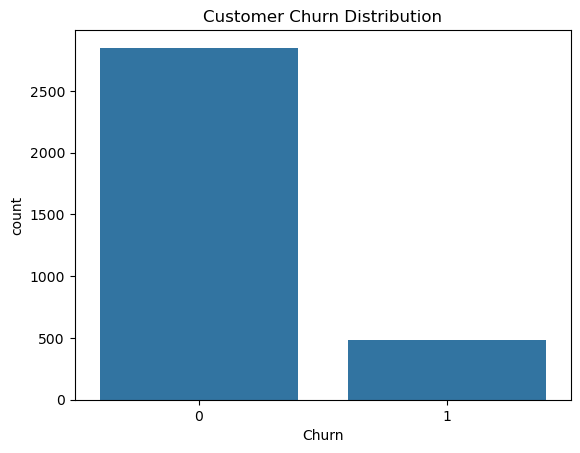

In [11]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [12]:
df['Churn'].value_counts(normalize=True)*100

Churn
0    85.508551
1    14.491449
Name: proportion, dtype: float64

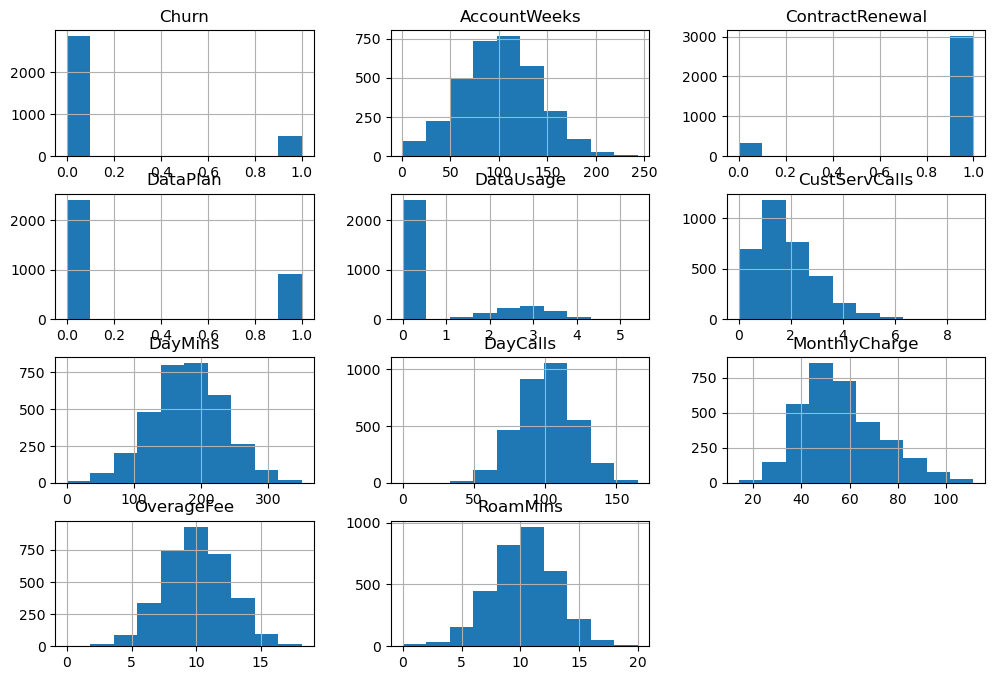

In [13]:
df.hist(figsize=(12,8))
plt.show()

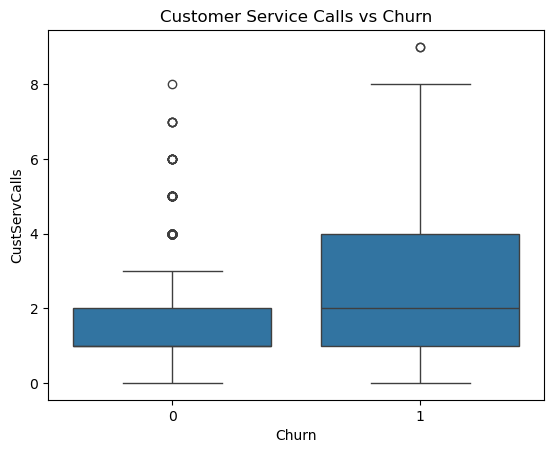

In [14]:
sns.boxplot(x='Churn', y='CustServCalls', data=df)
plt.title("Customer Service Calls vs Churn")
plt.show()

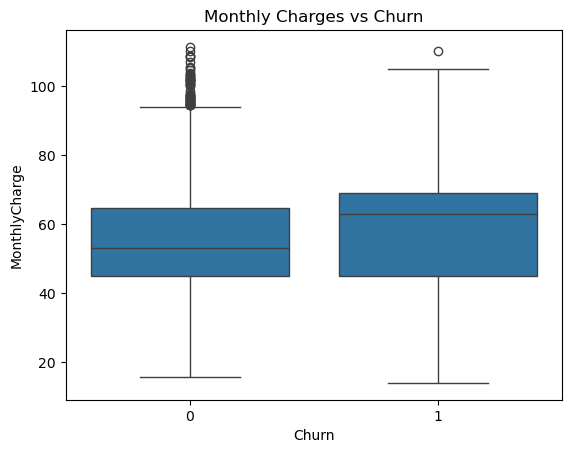

In [15]:
sns.boxplot(x='Churn', y='MonthlyCharge', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

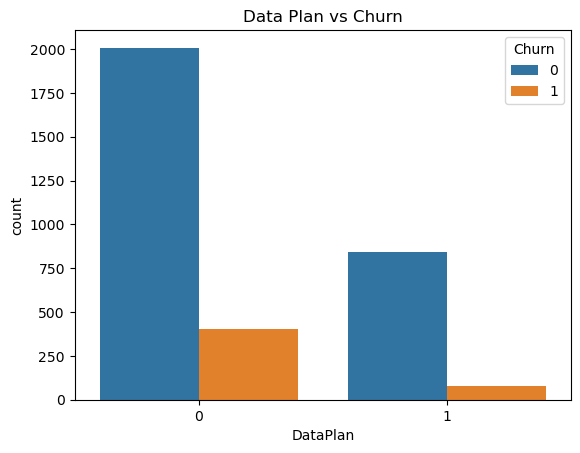

In [16]:
sns.countplot(x='DataPlan', hue='Churn', data=df)
plt.title("Data Plan vs Churn")
plt.show()

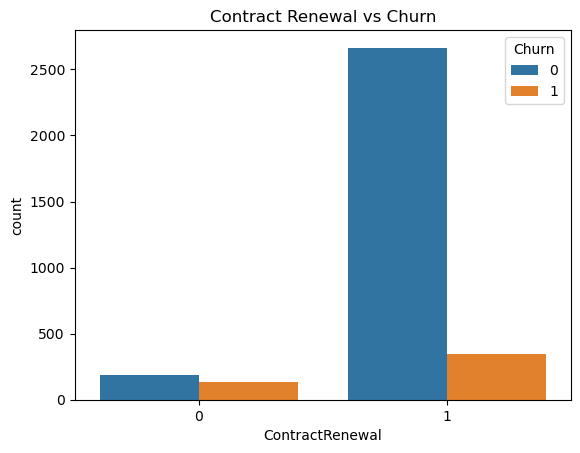

In [17]:
sns.countplot(x='ContractRenewal', hue='Churn', data=df)
plt.title("Contract Renewal vs Churn")
plt.show()

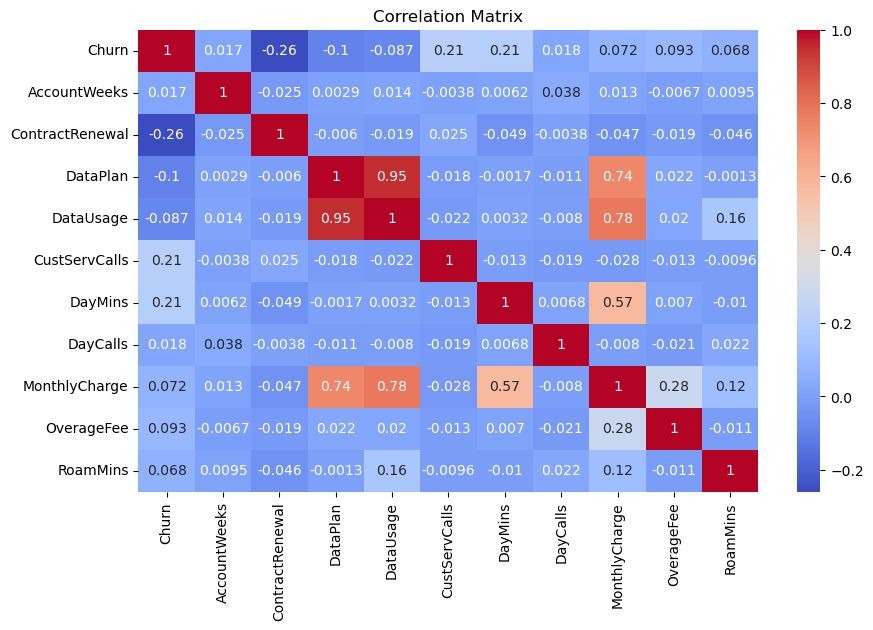

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='Churn', ylabel='DataUsage'>

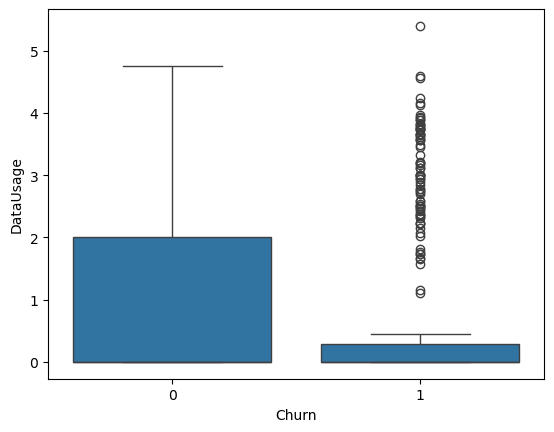

In [19]:
sns.boxplot(x='Churn', y='DataUsage', data=df)

<Axes: xlabel='Churn', ylabel='RoamMins'>

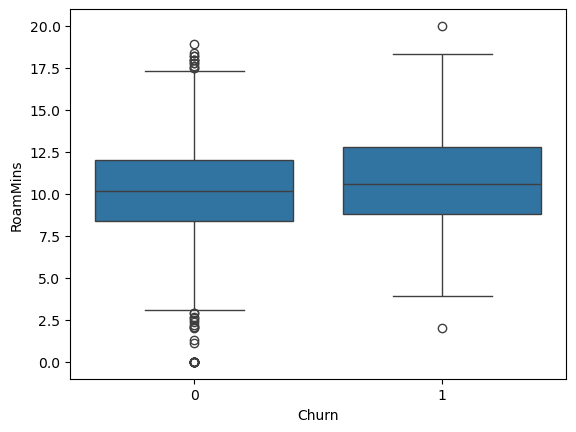

In [20]:
sns.boxplot(x='Churn', y='RoamMins', data=df)

## Key Business Insights from EDA

EDA revealed that customers who contacted customer support multiple times tend to churn more frequently.
This suggests dissatisfaction with service quality or unresolved issues. Reducing support complaints may help improve retention.

Customers paying higher monthly charges show a greater tendency to churn compared to those with lower charges.
This indicates that pricing may influence customer retention, and competitive pricing strategies could reduce churn.

Customers who did not renew their contracts have a much higher churn rate.
Encouraging contract renewals through incentives or loyalty programs could help retain customers.

Customers with fewer account weeks are more likely to churn.
This indicates that new customers are at higher risk of leaving, highlighting the importance of onboarding and early engagement.

Customers who use more roaming minutes tend to show slightly higher churn rates.
This could indicate dissatisfaction with roaming charges or service quality while traveling.

Customers with higher data usage show noticeable behavioral differences compared to those who remain.
Understanding these usage patterns may help design better plans tailored to customer needs.

Based on the analysis, telecom companies should focus on:

• customers with many service complaints

• customers paying high monthly charges

• customers who have not renewed contracts

• new customers with low tenure

Targeted retention strategies for these segments could significantly reduce churn.